# IMPORTING PAKAGES

In [72]:
#Importing pandas library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam
import tensorflow as tf

# LOADING DATASTES

In [73]:
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [74]:
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/DSPL/DATASETS/Hotel-A-train_Cleaned_Final.csv")
df_val=pd.read_csv("/content/drive/MyDrive/Colab Notebooks/DSPL/DATASETS/Hotel-A-validation_cleaned.CSV")

In [75]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27499 entries, 0 to 27498
Data columns (total 26 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   Reservation-id          27499 non-null  int64 
 1   Gender                  27499 non-null  object
 2   Age                     27499 non-null  int64 
 3   Ethnicity               27499 non-null  object
 4   Educational_Level       27499 non-null  object
 5   Income                  27499 non-null  object
 6   Country_region          27499 non-null  object
 7   Hotel_Type              27499 non-null  object
 8   Expected_checkin        27499 non-null  object
 9   Expected_checkout       27499 non-null  object
 10  Booking_date            27499 non-null  object
 11  Adults                  27499 non-null  int64 
 12  Children                27499 non-null  int64 
 13  Babies                  27499 non-null  int64 
 14  Meal_Type               27499 non-null  object
 15  Vi

In [76]:
df_val.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2733 entries, 0 to 2732
Data columns (total 26 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   Reservation-id          2733 non-null   int64 
 1   Gender                  2733 non-null   object
 2   Age                     2733 non-null   int64 
 3   Ethnicity               2733 non-null   object
 4   Educational_Level       2733 non-null   object
 5   Income                  2733 non-null   object
 6   Country_region          2733 non-null   object
 7   Hotel_Type              2733 non-null   object
 8   Expected_checkin        2733 non-null   object
 9   Expected_checkout       2733 non-null   object
 10  Booking_date            2733 non-null   object
 11  Adults                  2733 non-null   int64 
 12  Children                2733 non-null   int64 
 13  Babies                  2733 non-null   int64 
 14  Meal_Type               2733 non-null   object
 15  Vist

In [77]:
df.isnull().sum()

,0
Reservation-id,0
Gender,0
Age,0
Ethnicity,0
Educational_Level,0
Income,0
Country_region,0
Hotel_Type,0
Expected_checkin,0
Expected_checkout,0


In [78]:
df.columns = df.columns.str.title()
df_val.columns = df_val.columns.str.title()
# Renaming for consistency with df
df_val = df_val.rename(columns={'Lead_Time_Days': 'Lead_Time',
                                'Stay_Duration_Nights': 'Length_Of_Stay',
                                'Visited_Previously': 'Visted_Previously'})
df_val['Reservation_Status'] = df_val['Reservation_Status'].replace('Check-In', 'Check-Out')

In [79]:
df.isnull().sum()

,0
Reservation-Id,0
Gender,0
Age,0
Ethnicity,0
Educational_Level,0
Income,0
Country_Region,0
Hotel_Type,0
Expected_Checkin,0
Expected_Checkout,0


In [80]:
df_val.isnull().sum()

,0
Reservation-Id,0
Gender,0
Age,0
Ethnicity,0
Educational_Level,0
Income,0
Country_Region,0
Hotel_Type,0
Expected_Checkin,0
Expected_Checkout,0


In [81]:
df.Reservation_Status.value_counts()

,count
Reservation_Status,
Check-Out,21240
Canceled,4134
No-Show,2125


In [82]:
df_val.Reservation_Status.value_counts()

,count
Reservation_Status,
Check-Out,1602
Canceled,738
No-Show,393


# FEATURE ENGINEERING

In [83]:
# creating a new variable to calculate total number of guests per each reservation
df['Total_Guests'] = (df['Adults'] + df['Children'] + df['Babies'])
df_val['Total_Guests'] = (df_val['Adults'] + df_val['Children'] + df_val['Babies'])

In [84]:
# creating features to capture the seasonalities
df['Expected_Checkin'] = pd.to_datetime(df['Expected_Checkin'])
df_val['Expected_Checkin'] = pd.to_datetime(df_val['Expected_Checkin'])

df['Checkin_Month'] = df['Expected_Checkin'].dt.month
df_val['Checkin_Month'] = df_val['Expected_Checkin'].dt.month

df['Booking_Date'] = pd.to_datetime(df['Booking_Date'])
df_val['Booking_Date'] = pd.to_datetime(df_val['Booking_Date'])

df['Booking_Month'] = df['Booking_Date'].dt.month
df_val['Booking_Month'] = df_val['Booking_Date'].dt.month


In [85]:
# creating business related features
df['Actual_Room_Rate']   = df['Room_Rate'] * (1 - df['Discount_Rate'] / 100)
df_val['Actual_Room_Rate']   = df_val['Room_Rate'] * (1 - df_val['Discount_Rate'] / 100)

df['Price_Per_Guest'] = df['Actual_Room_Rate'] / df['Total_Guests']
df_val['Price_Per_Guest'] = df_val['Actual_Room_Rate'] / df_val['Total_Guests']

In [86]:
df['Lead_Time_Category'] = pd.cut(
    df['Lead_Time'],
    # Added float('-inf') at the start
    bins=[float('-inf'),0, 7, 30, 90, 365, float('inf')],
    # Added 'Invalid/Negative' at the start to match the new bin
    labels=['post bookings', 'Last_Minute', 'Short', 'Medium', 'Long', 'VeryLong']
)
df_val['Lead_Time_Category'] = pd.cut(
    df_val['Lead_Time'],
    # Added float('-inf') at the start
    bins=[float('-inf'),0, 7, 30, 90, 365, float('inf')],
    # Added 'Invalid/Negative' at the start to match the new bin
    labels=['post bookings', 'Last_Minute', 'Short', 'Medium', 'Long', 'VeryLong']
)



# preprocessing

In [87]:
df_val['Reservation_Status'] = df_val['Reservation_Status'].replace('Check-In', 'Check-Out')


In [88]:
df['Reservation_Status'] = df['Reservation_Status'].str.lower()
df_val['Reservation_Status'] = df_val['Reservation_Status'].str.lower()

In [89]:
#deleting the unwanted variables and creating Features for training data
training_feature_cols = df.drop(
['Reservation-Id','Expected_Checkin','Expected_Checkout','Booking_Date'],axis=1)

#deleting the unwanted variables and creating Features for training data
testing_feature_cols = df_val.drop(
['Reservation-Id','Expected_Checkin','Expected_Checkout','Booking_Date'],axis=1)

In [90]:
#split dataset in features and target variable
dependent_variable='Reservation_Status' # Target variable

X_train = training_feature_cols.drop(columns=[dependent_variable])
y_train = df[dependent_variable]

X_val = testing_feature_cols.drop(columns=[dependent_variable])
y_val = df_val[dependent_variable]

In [91]:
import pandas as pd

# Get the original column names from the feature selection step
# These are the columns that X_train and X_val should have before any transformations to ndarray
original_X_train_cols = training_feature_cols.drop(columns=[dependent_variable]).columns
original_X_val_cols = testing_feature_cols.drop(columns=[dependent_variable]).columns

# Ensure DataFrame format BEFORE pipeline
if not isinstance(X_train, pd.DataFrame):
    X_train = pd.DataFrame(X_train, columns=original_X_train_cols)

if not isinstance(X_val, pd.DataFrame):
    X_val = pd.DataFrame(X_val, columns=original_X_val_cols)

ENCODING

In [92]:
#lable encoding
le= LabelEncoder()
y_train = le.fit_transform(y_train)

y_val = le.transform(y_val)

In [93]:
binary_cols_train = [
    'Visted_Previously','Previous_Cancellations',
    'Use_Promotion','Required_Car_Parking'
]
X_train[binary_cols_train] = X_train[binary_cols_train].replace({'Yes':1, 'No':0}).astype(int)

binary_cols_val = [
    'Visted_Previously','Previous_Cancellations',
    'Use_Promotion','Required_Car_Parking'
]
X_val[binary_cols_val] = X_val[binary_cols_val].replace({'Yes':1, 'No':0}).astype(int)

/tmp/ipykernel_3631/3926920357.py:5: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X_train[binary_cols_train] = X_train[binary_cols_train].replace({'Yes':1, 'No':0}).astype(int)
/tmp/ipykernel_3631/3926920357.py:11: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X_val[binary_cols_val] = X_val[binary_cols_val].replace({'Yes':1, 'No':0}).astype(int)


In [94]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

# -----------------------------
# 1. Define column groups
# -----------------------------
one_hot_cols = ['Gender','Ethnicity','Country_Region','Hotel_Type',
                'Meal_Type','Deposit_Type','Booking_Channel']

ordinal_cols = ['Educational_Level', 'Income', 'Lead_Time_Category']

numeric_cols = [
    'Age', 'Adults', 'Children', 'Babies',
    'Length_Of_Stay', 'Visted_Previously', 'Room_Rate', 'Discount_Rate',
    'Lead_Time', 'Actual_Room_Rate', 'Price_Per_Guest', 'Total_Guests',
    'Checkin_Month', 'Booking_Month']


# Numeric pipeline
numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# One-hot categorical pipeline
onehot_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Ordinal categorical pipeline
ordinal_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ordinal', OrdinalEncoder())
])

preprocessor = ColumnTransformer([
    ('num', numeric_pipeline, numeric_cols),
    ('onehot', onehot_pipeline, one_hot_cols),
    ('ord', ordinal_pipeline, ordinal_cols)
])

# Apply pipeline
X_train_processed = preprocessor.fit_transform(X_train)
X_val_processed   = preprocessor.transform(X_val)

In [95]:
#one-hot encoding
y_val_cat = to_categorical(y_val)
y_train_cat = to_categorical(y_train)

# MODELING


ANN MODEL

In [96]:
def f1_macro(y_true, y_pred):
    y_pred_labels = tf.cast(tf.argmax(y_pred, axis=1), tf.int32)
    y_true_labels = tf.cast(tf.argmax(y_true, axis=1), tf.int32)
    f1_scores = []
    for c in range(3):  # one F1 per class, then average
        true_c = tf.cast(tf.equal(y_true_labels, c), tf.float32)
        pred_c = tf.cast(tf.equal(y_pred_labels, c), tf.float32)
        tp = tf.reduce_sum(true_c * pred_c)
        fp = tf.reduce_sum((1 - true_c) * pred_c)
        fn = tf.reduce_sum(true_c * (1 - pred_c))
        precision = tp / (tp + fp + 1e-8)
        recall    = tp / (tp + fn + 1e-8)
        f1 = 2 * precision * recall / (precision + recall + 1e-8)
        f1_scores.append(f1)
    return tf.reduce_mean(tf.stack(f1_scores))

In [97]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

classes = np.unique(y_train) # Use y_train for actual class labels
class_weights_dict = dict(zip(
    classes,
    compute_class_weight(class_weight='balanced', classes=classes, y=y_train) # Pass classes and y as keyword arguments and use y_train
))

In [98]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Input
from tensorflow.keras.regularizers import l2

model = Sequential([
    Input(shape=(X_train_processed.shape[1],)),
    Dense(512, activation='relu', kernel_regularizer=l2(1e-4)),
    BatchNormalization(),
    Dropout(0.3),
    Dense(128, activation='relu', kernel_regularizer=l2(1e-4)),
    BatchNormalization(),
    Dropout(0.2),
    Dense(64, activation='relu', kernel_regularizer=l2(1e-4)),
    Dropout(0.2),
    Dense(y_train_cat.shape[1], activation='softmax')  # dynamic output size
])

In [99]:
model.compile(
    optimizer=Adam(learning_rate=0.00001, clipnorm=1.0),
    loss=tf.keras.losses.CategoricalFocalCrossentropy(gamma=2.0),
    metrics=['accuracy',f1_macro]
)

In [100]:
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping

callbacks = [
    ReduceLROnPlateau(monitor='val_f1_macro', patience=5, factor=0.5, verbose=1, mode='max'),
    EarlyStopping(monitor='val_f1_macro', patience=15, restore_best_weights=True, mode='max')
]

In [101]:
history = model.fit(
    X_train_processed,
    y_train_cat,
    validation_data=(X_val_processed, y_val_cat),
    epochs=100,
    batch_size=32,
    class_weight=class_weights_dict,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/100
860/860 ━━━━━━━━━━━━━━━━━━━━ 32s 22ms/step - accuracy: 0.3494 - f1_macro: 0.2645 - loss: 0.2760 - val_accuracy: 0.3264 - val_f1_macro: 0.2874 - val_loss: 0.1976 - learning_rate: 1.0000e-05
Epoch 2/100
860/860 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.3550 - f1_macro: 0.2700 - loss: 0.2527 - val_accuracy: 0.3348 - val_f1_macro: 0.2975 - val_loss: 0.1916 - learning_rate: 1.0000e-05
Epoch 3/100
860/860 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.3629 - f1_macro: 0.2767 - loss: 0.2419 - val_accuracy: 0.3385 - val_f1_macro: 0.2998 - val_loss: 0.1887 - learning_rate: 1.0000e-05
Epoch 4/100
860/860 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.3636 - f1_macro: 0.2763 - loss: 0.2342 - val_accuracy: 0.3366 - val_f1_macro: 0.2964 - val_loss: 0.1864 - learning_rate: 1.0000e-05
Epoch 5/100
860/860 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.3755 - f1_macro: 0.2872 - loss: 0.2247 - val_accuracy: 0.3392 - val_f1_macro: 0.2968 - val_loss: 0.1849 - learning_rate: 1.0000e-05
E

In [102]:

import numpy as np
from sklearn.metrics import classification_report, f1_score

y_pred_ann = np.argmax(model.predict(X_val_processed), axis=1)
print(classification_report(y_val, y_pred_ann, ))
print("Macro F1:", f1_score(y_val, y_pred_ann, average='macro'))

86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
              precision    recall  f1-score   support

           0       0.28      0.42      0.34       738
           1       0.61      0.30      0.41      1602
           2       0.16      0.32      0.21       393

    accuracy                           0.34      2733
   macro avg       0.35      0.35      0.32      2733
weighted avg       0.45      0.34      0.36      2733

Macro F1: 0.31712259734373416


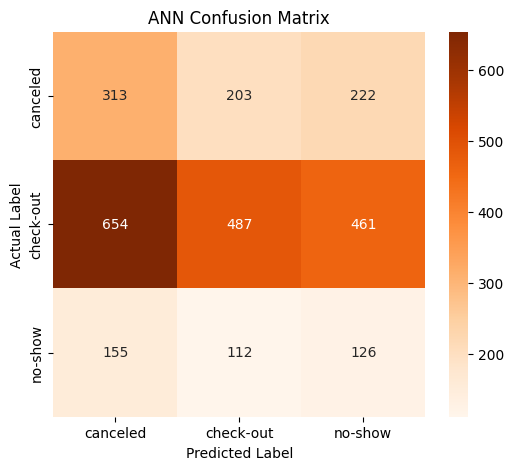

In [103]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Generate confusion matrix
cm = confusion_matrix(y_val, y_pred_ann)

# Plot confusion matrix
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=le.classes_,
            yticklabels=le.classes_)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("ANN Confusion Matrix")
plt.show()

ANN WITH ADASYN


In [104]:
import numpy as np
print(np.unique(y_train, return_counts=True))

(array([0, 1, 2]), array([ 4134, 21240,  2125]))


In [105]:
from imblearn.over_sampling import ADASYN
import numpy as np

adasyn = ADASYN(
    sampling_strategy={
        0: 12402,   # canceled  ( 4134, 3× original)
        2: 8500     # no-show   (2125, 4× original)
    },
    n_neighbors=5,
    random_state=42
)

X_train_resampled, y_train_resampled = adasyn.fit_resample(
    X_train_processed, y_train
)

print(np.unique(y_train_resampled, return_counts=True))

(array([0, 1, 2]), array([11584, 21240,  8358]))


In [106]:
#one-hot encoding
y_val_cat = to_categorical(y_val)
y_train_cat_a = to_categorical(y_train_resampled)

In [107]:
model_adasyn = Sequential([
    Input(shape=(X_train_resampled.shape[1],)),
    Dense(256, activation='relu', kernel_regularizer=l2(1e-4)),
    BatchNormalization(),
    Dropout(0.3),
    Dense(128, activation='relu', kernel_regularizer=l2(1e-4)),
    BatchNormalization(),
    Dropout(0.3),
    Dense(64, activation='relu', kernel_regularizer=l2(1e-4)),
    BatchNormalization(),
    Dropout(0.2),
    Dense(3, activation='softmax')
])

In [108]:

model_adasyn.compile(
    optimizer=Adam(learning_rate=0.00001),
    loss=tf.keras.losses.CategoricalFocalCrossentropy(gamma=2.0),
    metrics=['accuracy', f1_macro]
)

In [109]:
callbacks_adasyn = [
    ReduceLROnPlateau(monitor='val_f1_macro', patience=5, factor=0.5, verbose=1, mode='max'),
    EarlyStopping(monitor='val_f1_macro', patience=15, restore_best_weights=True, mode='max')
]

In [110]:
# 5. Train (no class_weight needed — SMOTE already balanced the classes)
history_adasyn = model_adasyn.fit(
    X_train_resampled, y_train_cat_a,
    validation_data=(X_val_processed, y_val_cat),
    epochs=100,
    batch_size=64,
    callbacks=callbacks_adasyn,
    verbose=1
)

Epoch 1/100
644/644 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - accuracy: 0.3308 - f1_macro: 0.3158 - loss: 0.3327 - val_accuracy: 0.3041 - val_f1_macro: 0.2869 - val_loss: 0.2332 - learning_rate: 1.0000e-05
Epoch 2/100
644/644 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.3441 - f1_macro: 0.3271 - loss: 0.3048 - val_accuracy: 0.3139 - val_f1_macro: 0.2916 - val_loss: 0.2180 - learning_rate: 1.0000e-05
Epoch 3/100
644/644 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.3559 - f1_macro: 0.3365 - loss: 0.2822 - val_accuracy: 0.3213 - val_f1_macro: 0.2988 - val_loss: 0.2073 - learning_rate: 1.0000e-05
Epoch 4/100
644/644 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.3626 - f1_macro: 0.3397 - loss: 0.2692 - val_accuracy: 0.3333 - val_f1_macro: 0.3076 - val_loss: 0.1994 - learning_rate: 1.0000e-05
Epoch 5/100
644/644 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.3711 - f1_macro: 0.3465 - loss: 0.2564 - val_accuracy: 0.3381 - val_f1_macro: 0.3057 - val_loss: 0.1927 - learning_rate: 1.0000e-05
Epo

In [111]:
import numpy as np
from sklearn.metrics import classification_report, f1_score

y_pred_ann_s = np.argmax(model_adasyn.predict(X_val_processed), axis=1)
print(classification_report(y_val, y_pred_ann_s, target_names=le.classes_))
print("Macro F1:", f1_score(y_val, y_pred_ann_s, average='macro'))

86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
              precision    recall  f1-score   support

    canceled       0.27      0.25      0.26       738
   check-out       0.60      0.62      0.61      1602
     no-show       0.16      0.17      0.16       393

    accuracy                           0.45      2733
   macro avg       0.34      0.34      0.34      2733
weighted avg       0.45      0.45      0.45      2733

Macro F1: 0.3422001214299042


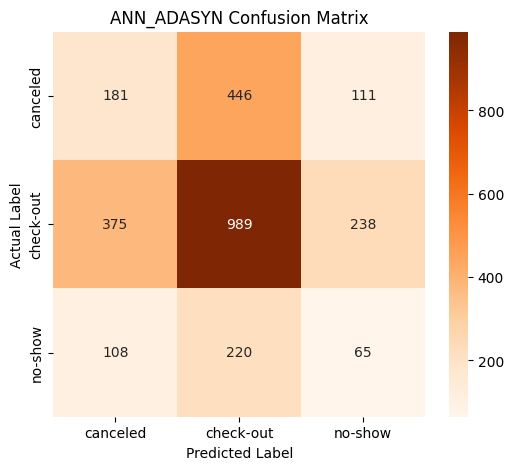

In [112]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Generate confusion matrix
cm = confusion_matrix(y_val, y_pred_ann_s)

# Plot confusion matrix
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=le.classes_,
            yticklabels=le.classes_)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("ANN_ADASYN Confusion Matrix")
plt.show()

XGBooster

In [113]:
# ── Fixed XGBoost — remove invalid class_weight ───────────────────────
from xgboost import XGBClassifier
from sklearn.metrics import classification_report

xgb = XGBClassifier(
    n_estimators=1000,
    learning_rate=0.05,        # fix: was 0.0001, far too slow
    max_depth=6,               # fix: was 8, reduce to avoid overfitting
    subsample=0.8,
    colsample_bytree=0.7,
    min_child_weight=3,
    gamma=0.1,
    objective='multi:softmax',
    num_class=len(classes),
    eval_metric='mlogloss',
    early_stopping_rounds=50,
    random_state=42,
    # REMOVED: class_weight='balanced'  ← invalid parameter, silently ignored
)
class_counts = np.bincount(y_train)
total = len(y_train)
sample_weight = np.array([total / (3 * class_counts[yi]) for yi in y_train])

xgb.fit(X_train_processed, y_train,
        sample_weight=sample_weight,   # ← add this
        eval_set=[(X_val_processed, y_val)],
        verbose=False)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.7, device=None, early_stopping_rounds=50,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=0.1,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=3, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=1000, n_jobs=None, num_class=3, ...)

In [114]:
y_pred_xgb = np.argmax(xgb.predict_proba(X_val_processed), axis=1)
print(classification_report(y_val, y_pred_xgb, target_names=le.classes_))

              precision    recall  f1-score   support

    canceled       0.34      0.28      0.31       738
   check-out       0.61      0.37      0.46      1602
     no-show       0.15      0.44      0.22       393

    accuracy                           0.35      2733
   macro avg       0.36      0.36      0.33      2733
weighted avg       0.47      0.35      0.38      2733



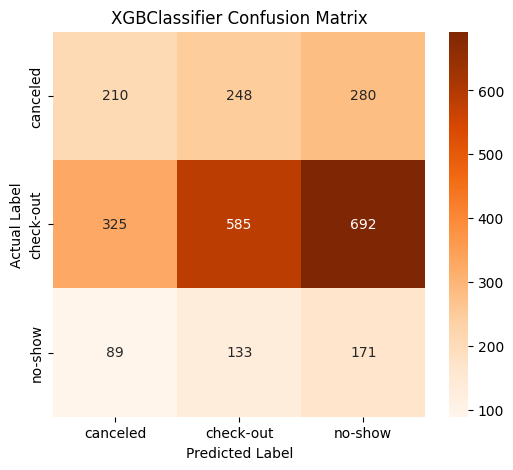

In [115]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Generate confusion matrix
cm = confusion_matrix(y_val, y_pred_xgb)

# Plot confusion matrix
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=le.classes_,
            yticklabels=le.classes_)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("XGBClassifier Confusion Matrix")
plt.show()

LGBMClassifier

In [116]:
from lightgbm import LGBMClassifier
import lightgbm # Added this import
from sklearn.metrics import classification_report # Added this import

lgbm = LGBMClassifier(
    n_estimators=1000,
    learning_rate=0.02,
    class_weight='balanced',
    random_state=42
)
lgbm.fit(X_train_processed, y_train,
         eval_set=[(X_val_processed, y_val)],
         eval_metric='multi_logloss',
         callbacks=[lightgbm.early_stopping(stopping_rounds=50, verbose=False)])


LGBMClassifier(class_weight='balanced', learning_rate=0.02, n_estimators=1000,
               random_state=42)

In [117]:
y_pred_lgbm = np.argmax(lgbm.predict_proba(X_val_processed), axis=1)
print(classification_report(y_val,y_pred_lgbm, target_names=le.classes_))

              precision    recall  f1-score   support

    canceled       0.27      0.30      0.28       738
   check-out       0.61      0.34      0.43      1602
     no-show       0.14      0.36      0.20       393

    accuracy                           0.33      2733
   macro avg       0.34      0.33      0.31      2733
weighted avg       0.45      0.33      0.36      2733



/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


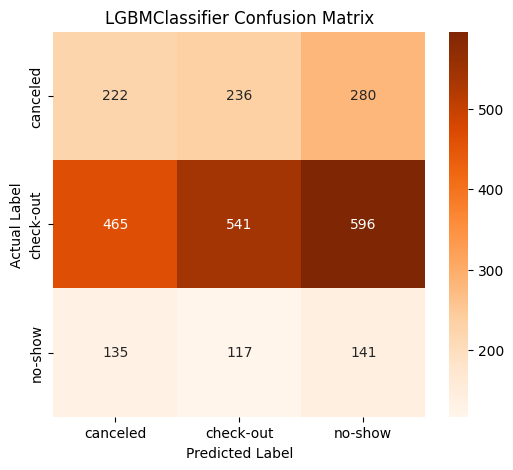

In [118]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Generate confusion matrix
cm = confusion_matrix(y_val, y_pred_lgbm)

# Plot confusion matrix
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=le.classes_,
            yticklabels=le.classes_)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("LGBMClassifier Confusion Matrix")
plt.show()

# STACKING ENSEMBLE


In [119]:
import numpy as np
from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, f1_score
from sklearn.utils.class_weight import compute_class_weight
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Input
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

In [120]:
class_counts = np.bincount(y_train)
total = len(y_train)
sample_weight_train = np.array([total / (3 * class_counts[yi]) for yi in y_train])

In [121]:
def f1_macro(y_true, y_pred):
    y_pred_labels = tf.cast(tf.argmax(y_pred, axis=1), tf.int32)
    y_true_labels = tf.cast(tf.argmax(y_true, axis=1), tf.int32)
    f1_scores = []
    for c in range(3):
        true_c = tf.cast(tf.equal(y_true_labels, c), tf.float32)
        pred_c = tf.cast(tf.equal(y_pred_labels, c), tf.float32)
        tp = tf.reduce_sum(true_c * pred_c)
        fp = tf.reduce_sum((1 - true_c) * pred_c)
        fn = tf.reduce_sum(true_c * (1 - pred_c))
        p  = tp / (tp + fp + 1e-8)
        r  = tp / (tp + fn + 1e-8)
        f1_scores.append(2 * p * r / (p + r + 1e-8))
    return tf.reduce_mean(tf.stack(f1_scores))

In [ ]:
import numpy as np
from sklearn.model_selection import StratifiedKFold
from sklearn.utils.class_weight import compute_class_weight

N_FOLDS = 5
N_CLASSES = 3
cv = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)

# Placeholder arrays: each model contributes 3 probability columns
xgb_oof  = np.zeros((len(X_train_processed), N_CLASSES))
lgbm_oof = np.zeros((len(X_train_processed), N_CLASSES))
ann_oof  = np.zeros((len(X_train_processed), N_CLASSES))

xgb_val_preds  = np.zeros((len(X_val_processed), N_CLASSES))
lgbm_val_preds = np.zeros((len(X_val_processed), N_CLASSES))
ann_val_preds  = np.zeros((len(X_val_processed), N_CLASSES))

# Precompute sample weights
class_counts = np.bincount(y_train)
total = len(y_train)
sample_weight_train = np.array([total / (3 * class_counts[yi]) for yi in y_train])

for fold, (tr_idx, vl_idx) in enumerate(cv.split(X_train_processed, y_train)):
    print(f"\n── Fold {fold+1}/{N_FOLDS} ──")
    Xtr, Xvl = X_train_processed[tr_idx], X_train_processed[vl_idx]
    ytr, yvl = y_train[tr_idx], y_train[vl_idx]
    sw = sample_weight_train[tr_idx]

    # XGBoost
    xgb_fold = XGBClassifier(
        n_estimators=600, learning_rate=0.05, max_depth=6,
        subsample=0.8, colsample_bytree=0.7, min_child_weight=3,
        gamma=0.1, reg_alpha=0.1, reg_lambda=1.0,
        objective='multi:softprob', num_class=N_CLASSES,
        eval_metric='mlogloss', early_stopping_rounds=40,
        random_state=42, use_label_encoder=False, verbosity=0
    )
    xgb_fold.fit(Xtr, ytr, sample_weight=sw,
                 eval_set=[(Xvl, yvl)], verbose=False)
    xgb_oof[vl_idx]   = xgb_fold.predict_proba(Xvl)
    xgb_val_preds     += xgb_fold.predict_proba(X_val_processed) / N_FOLDS

    #  LightGBM
    import lightgbm as lgb
    lgbm_fold = LGBMClassifier(
        n_estimators=1000, learning_rate=0.02, num_leaves=63,
        min_child_samples=20, subsample=0.8, colsample_bytree=0.8,
        reg_alpha=0.1, reg_lambda=1.0,
        class_weight='balanced', random_state=42, verbose=-1
    )
    lgbm_fold.fit(Xtr, ytr,
                  eval_set=[(Xvl, yvl)], eval_metric='multi_logloss',
                  callbacks=[lgb.early_stopping(50, verbose=False)])
    lgbm_oof[vl_idx]  = lgbm_fold.predict_proba(Xvl)
    lgbm_val_preds    += lgbm_fold.predict_proba(X_val_processed) / N_FOLDS

    #  ANN
    classes_fold = np.unique(ytr)
    cw_fold = compute_class_weight('balanced', classes=classes_fold, y=ytr)
    cw_dict = dict(zip(classes_fold, cw_fold))

    ann_fold = Sequential([
        Input(shape=(Xtr.shape[1],)),
        Dense(256, activation='relu', kernel_regularizer=l2(1e-4)),
        BatchNormalization(), Dropout(0.4),
        Dense(128, activation='relu', kernel_regularizer=l2(1e-4)),
        BatchNormalization(), Dropout(0.3),
        Dense(64,  activation='relu', kernel_regularizer=l2(1e-4)),
        BatchNormalization(), Dropout(0.2),
        Dense(N_CLASSES, activation='softmax')
    ])
    ann_fold.compile(
        optimizer=Adam(learning_rate=0.001, clipnorm=1.0),
        loss=tf.keras.losses.CategoricalFocalCrossentropy(gamma=2.0),
        metrics=[f1_macro]
    )
    ytr_cat = to_categorical(ytr, N_CLASSES)
    yvl_cat = to_categorical(yvl, N_CLASSES)
    cb_fold = [
        EarlyStopping(monitor='val_f1_macro', patience=10,
                      restore_best_weights=True, mode='max'),
        ReduceLROnPlateau(monitor='val_f1_macro', patience=5,
                          factor=0.5, mode='max', verbose=0)
    ]
    ann_fold.fit(Xtr, ytr_cat, validation_data=(Xvl, yvl_cat),
                 epochs=60, batch_size=64,
                 class_weight=cw_dict, callbacks=cb_fold, verbose=0)
    ann_oof[vl_idx]  = ann_fold.predict(Xvl, verbose=0)
    ann_val_preds   += ann_fold.predict(X_val_processed, verbose=0) / N_FOLDS
    print(f"  Fold {fold+1} complete.")

print("\nOOF generation done.")

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Generate confusion matrix
cm = confusion_matrix(y_val, y_pred_stack)

# Plot confusion matrix
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=le.classes_,
            yticklabels=le.classes_)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Stacking_Ensemble Confusion Matrix")
plt.show()

# HYPERPARAMETER TUNING



In [ ]:
!pip install optuna -q
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

XGBClassifier

In [ ]:
from xgboost import XGBClassifier
from sklearn.metrics import f1_score

class_counts = np.bincount(y_train)
total = len(y_train)
sample_weight_train = np.array([total / (3 * class_counts[yi]) for yi in y_train])

def xgb_objective(trial):
    params = {
        'n_estimators':        trial.suggest_int('n_estimators', 300, 1000),
        'learning_rate':       trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'max_depth':           trial.suggest_int('max_depth', 3, 8),
        'subsample':           trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree':    trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'min_child_weight':    trial.suggest_int('min_child_weight', 1, 10),
        'gamma':               trial.suggest_float('gamma', 0.0, 1.0),
        'reg_alpha':           trial.suggest_float('reg_alpha', 1e-4, 10.0, log=True),
        'reg_lambda':          trial.suggest_float('reg_lambda', 1e-4, 10.0, log=True),
        'objective':           'multi:softprob',
        'num_class':           3,
        'eval_metric':         'mlogloss',
        'early_stopping_rounds': 40,
        'random_state':        42,
        'use_label_encoder':   False,
        'verbosity':           0,
    }
    m = XGBClassifier(**params)
    m.fit(X_train_processed, y_train,
          sample_weight=sample_weight_train,
          eval_set=[(X_val_processed, y_val)],
          verbose=False)
    preds = np.argmax(m.predict_proba(X_val_processed), axis=1)
    return f1_score(y_val, preds, average='macro')

study_xgb = optuna.create_study(direction='maximize')
study_xgb.optimize(xgb_objective, n_trials=50, show_progress_bar=True)

print("\nBest XGBoost macro F1:", study_xgb.best_value)
print("Best XGBoost params:\n", study_xgb.best_params)

In [ ]:
# Rebuild with best params (early_stopping_rounds excluded for final model)
best_xgb_params = study_xgb.best_params.copy()

xgb_best = XGBClassifier(
    **best_xgb_params,
    objective='multi:softprob',
    num_class=3,
    eval_metric='mlogloss',
    random_state=42,
    use_label_encoder=False,
    verbosity=0
)
xgb_best.fit(X_train_processed, y_train, sample_weight=sample_weight_train, verbose=False)
print(classification_report(y_val, np.argmax(xgb_best.predict_proba(X_val_processed), axis=1), target_names=le.classes_))

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Generate confusion matrix
cm = confusion_matrix(y_val, np.argmax(xgb_best.predict_proba(X_val_processed), axis=1) )

# Plot confusion matrix
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_,
            yticklabels=le.classes_)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("XGBClassifier_Tuned Confusion Matrix")
plt.show()

LightGBM

In [ ]:
# ── LightGBM Optuna tuning ────────────────────────────────────────────
import lightgbm as lgb
from lightgbm import LGBMClassifier

def lgbm_objective(trial):
    params = {
        'n_estimators':       trial.suggest_int('n_estimators', 300, 1500),
        'learning_rate':      trial.suggest_float('learning_rate', 0.005, 0.1, log=True),
        'num_leaves':         trial.suggest_int('num_leaves', 20, 200),
        'max_depth':          trial.suggest_int('max_depth', 3, 12),
        'min_child_samples':  trial.suggest_int('min_child_samples', 10, 100),
        'subsample':          trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree':   trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'reg_alpha':          trial.suggest_float('reg_alpha', 1e-4, 10.0, log=True),
        'reg_lambda':         trial.suggest_float('reg_lambda', 1e-4, 10.0, log=True),
        'class_weight':       'balanced',
        'random_state':       42,
        'verbose':            -1,
    }
    m = LGBMClassifier(**params)
    m.fit(X_train_processed, y_train,
          eval_set=[(X_val_processed, y_val)],
          eval_metric='multi_logloss',
          callbacks=[lgb.early_stopping(50, verbose=False)])
    return f1_score(y_val, m.predict(X_val_processed), average='macro')

study_lgbm = optuna.create_study(direction='maximize')
study_lgbm.optimize(lgbm_objective, n_trials=50, show_progress_bar=True)

print("\nBest LightGBM macro F1:", study_lgbm.best_value)
print("Best LightGBM params:\n", study_lgbm.best_params)

In [ ]:
lgbm_best = LGBMClassifier(
    **study_lgbm.best_params,
    class_weight='balanced',
    random_state=42,
    verbose=-1
)
lgbm_best.fit(X_train_processed, y_train)
print(classification_report(y_val, lgbm_best.predict(X_val_processed), target_names=le.classes_))

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Generate confusion matrix
cm = confusion_matrix(y_val, lgbm_best.predict(X_val_processed) )

# Plot confusion matrix
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_,
            yticklabels=le.classes_)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("LGBMClassifier_Tuned Confusion Matrix")
plt.show()


ANN

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Input
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.utils.class_weight import compute_class_weight

classes = np.unique(y_train)
cw = compute_class_weight('balanced', classes=classes, y=y_train)
class_weights_dict = dict(zip(classes, cw))
y_train_cat = to_categorical(y_train, 3)
y_val_cat   = to_categorical(y_val,   3)

def ann_objective(trial):
    tf.random.set_seed(42)
    n_layers = trial.suggest_int('n_layers', 2,4)
    lr       = trial.suggest_float('lr', 1e-4, 1e-2, log=True)
    gamma    = trial.suggest_float('gamma', 0.5, 3.0)
    l2_reg   = trial.suggest_float('l2_reg', 1e-5, 1e-2, log=True)
    batch_sz = trial.suggest_categorical('batch_size', [32, 64, 128])

    layer_list = [Input(shape=(X_train_processed.shape[1],))]
    for i in range(n_layers):
        units   = trial.suggest_categorical(f'units_{i}', [64, 128, 256, 512])
        dropout = trial.suggest_float(f'dropout_{i}', 0.1, 0.5)
        layer_list += [
            Dense(units, activation='relu', kernel_regularizer=l2(l2_reg)),
            BatchNormalization(),
            Dropout(dropout)
        ]
    layer_list.append(Dense(3, activation='softmax'))

    model = Sequential(layer_list)
    model.compile(
        optimizer=Adam(learning_rate=lr, clipnorm=1.0),
        loss=tf.keras.losses.CategoricalFocalCrossentropy(gamma=gamma),
        metrics=[f1_macro]
    )
    cb = [
        EarlyStopping(monitor='val_f1_macro', patience=15,
                      restore_best_weights=True, mode='max'),
        ReduceLROnPlateau(monitor='val_f1_macro', patience=5,
                          factor=0.5, mode='max', verbose=0)
    ]
    model.fit(X_train_processed, y_train_cat,
              validation_data=(X_val_processed, y_val_cat),
              epochs=80, batch_size=batch_sz,
              class_weight=class_weights_dict,
              callbacks=cb, verbose=0)
    preds = np.argmax(model.predict(X_val_processed, verbose=0), axis=1)
    return f1_score(y_val, preds, average='macro')

study_ann = optuna.create_study(direction='maximize')
study_ann.optimize(ann_objective, n_trials=20, show_progress_bar=True)  # 20 trials — ANN is slow

print("\nBest ANN macro F1:", study_ann.best_value)
print("Best ANN params:\n", study_ann.best_params)

In [ ]:
best_ann = Sequential([
    Input(shape=(X_train_processed.shape[1],)),
    Dense(64, activation='relu', kernel_regularizer=l2(0.009938574688452684)),
    BatchNormalization(), Dropout(0.25523679664026716),
    Dense(64, activation='relu', kernel_regularizer=l2(0.009938574688452684)),
    BatchNormalization(), Dropout(0.25130711146926876),
    Dense(3, activation='softmax')
])
best_ann.compile(
    optimizer=Adam(learning_rate=0.0009829980119896867, clipnorm=1.0),
    loss=tf.keras.losses.CategoricalFocalCrossentropy(gamma=1.9633385769731966),
    metrics=[f1_macro]
)
cb_final = [
    EarlyStopping(monitor='val_f1_macro', patience=30,
                  restore_best_weights=True, mode='max'),
    ReduceLROnPlateau(monitor='val_f1_macro', patience=10,
                      factor=0.5, mode='max', verbose=1)
]
best_ann.fit(X_train_processed, y_train_cat,
             validation_data=(X_val_processed, y_val_cat),
             epochs=120, batch_size=32,
             class_weight=class_weights_dict,
             callbacks=cb_final, verbose=1)

y_pred_ann_final = np.argmax(best_ann.predict(X_val_processed, verbose=0), axis=1)
print(classification_report(y_val, y_pred_ann_final, target_names=le.classes_))
print("Macro F1:", f1_score(y_val, y_pred_ann_final, average='macro'))

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Generate confusion matrix
cm = confusion_matrix(y_val,y_pred_ann_final )

# Plot confusion matrix
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_,
            yticklabels=le.classes_)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("ANN_Tuned Confusion Matrix")
plt.show()
